# IntZ Example 17: Disk Assembly — V/σ Evolution ⭐ EPS Science
**EPS Research — Flynn & Cannaliato (2025)**

V/σ is a key disk settling indicator. This notebook examines how V/σ varies with redshift and stellar mass in IntZ, connecting to the disk assembly interpretation of omega sign reversal.

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'intz_corpus_v1b.json': 'https://zenodo.org/records/20453189/files/intz_corpus_v1b.json',
        'intz_corpus_v1b_flat.csv': 'https://zenodo.org/records/20453189/files/intz_corpus_v1b_flat.csv',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load IntZ corpus
with open('/home/david/Documents/RAG Project/Z=2 RAG/Zenodo/intz_corpus_v1b.json') as f:
    data = json.load(f)
galaxies = data['galaxies']
print(f"Loaded {len(galaxies)} galaxies")

Loaded 1292 galaxies


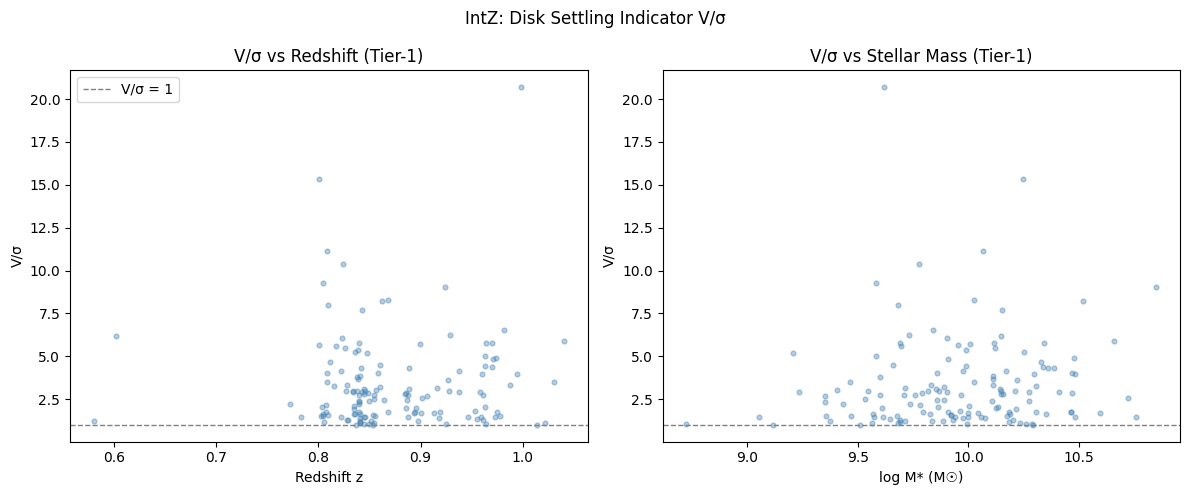

V/σ vs z:  rho=-0.001
V/σ vs M*: rho=0.149


In [3]:
data = []
for g in galaxies:
    if g['metadata']['quality_tier'] != 1: continue
    vos = g['kinematics'].get('v_over_sigma')
    z   = g['redshift']['z_spec']
    lm  = g['stellar_properties'].get('log_mass_msun')
    if vos and 0 < vos < 30 and z and lm:
        data.append((z, lm, vos))

z_v, lm_v, vos_v = zip(*data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(z_v, vos_v, c='steelblue', alpha=0.4, s=12)
axes[0].axhline(1, color='gray', ls='--', lw=1, label='V/σ = 1')
axes[0].set_xlabel('Redshift z')
axes[0].set_ylabel('V/σ')
axes[0].set_title('V/σ vs Redshift (Tier-1)')
axes[0].legend()

axes[1].scatter(lm_v, vos_v, c='steelblue', alpha=0.4, s=12)
axes[1].axhline(1, color='gray', ls='--', lw=1)
axes[1].set_xlabel('log M* (M☉)')
axes[1].set_ylabel('V/σ')
axes[1].set_title('V/σ vs Stellar Mass (Tier-1)')

plt.suptitle('IntZ: Disk Settling Indicator V/σ', fontsize=12)
plt.tight_layout()
plt.savefig('intz_nb17_disk_assembly.png', dpi=120)
plt.show()

from scipy.stats import spearmanr
print(f"V/σ vs z:  rho={spearmanr(z_v, vos_v).correlation:.3f}")
print(f"V/σ vs M*: rho={spearmanr(lm_v, vos_v).correlation:.3f}")